# Living Planet Index / RLPI Project

## Project goal

This project explores vertebrate population trends using data from the Living Planet Index / RLPI dataset.

The focus is on animals, biodiversity, population trends, and data quality — not climate.

## Main research direction

Which vertebrate populations are declining, recovering, or remaining stable, and how do these patterns vary across taxa and geographic regions?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_DIR = Path("../data/raw")
RLPI_DIR = RAW_DIR / "rlpi-master" / "inst" / "extdata" / "example_data"

files = list(RLPI_DIR.rglob("*_pops.txt"))

len(files), files[:10]

(19,
 [PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_IndoPacific_herps_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_IndoPacific_aves_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/example_data_nm_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_Nearctic_mammalia_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_Neotropical_mammalia_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_Neotropical_aves_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/terrestrial_Nearctic_Mammalia_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_Nearctic_herps_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_IndoPacific_mammalia_pops.txt'),
  PosixPath('../data/raw/rlpi-master/inst/extdata/example_data/T_Afrotropical_herps_pops.txt')])

In [2]:
first_file = files[0]

df = pd.read_csv(first_file, sep="\t")

df.head()

,Binomial,ID,year,popvalue
0,Tiliqua_rugosa,11973,1978,343.7
1,Naultinus_manukanus,17681,1978,29.0
2,Gavialis_gangeticus,5678,1979,107.0
3,Tiliqua_rugosa,11973,1979,395.5
4,Tiliqua_rugosa,11973,1980,390.4


In [7]:
df.columns

Index(['Binomial', 'ID', 'year', 'popvalue'], dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Binomial  352 non-null    object 
 1   ID        352 non-null    int64  
 2   year      352 non-null    int64  
 3   popvalue  352 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 11.1+ KB


In [4]:
df.describe(include="all")

,Binomial,ID,year,popvalue
count,352,352.000000,352.000000,352.000000
unique,36,NaN,NaN,NaN
top,Leiopelma_pakeka,NaN,NaN,NaN
freq,26,NaN,NaN,NaN
mean,NaN,12862.031250,2000.613636,132.167493
std,NaN,4335.122214,6.041512,742.568272
min,NaN,642.000000,1978.000000,0.000000
25%,NaN,11010.750000,1997.000000,0.289250
50%,NaN,11320.000000,2002.000000,28.970350
75%,NaN,17701.250000,2005.000000,110.000000


In [20]:
def parse_filename(file_name):
    name = file_name.replace("_pops.txt", "")
    parts = name.split("_")
    
    # Example:
    # T_IndoPacific_herps
    if parts[0] == "T":
        realm = parts[1]
        group = parts[2]
        system = "terrestrial"
    
    # Example:
    # terrestrial_Nearctic_Mammalia
    elif parts[0] == "terrestrial":
        system = "terrestrial"
        realm = parts[1]
        group = parts[2]
    
    # Example:
    # example_data_nm
    else:
        system = "unknown"
        realm = "unknown"
        group = "unknown"
    
    return system, realm, group

In [21]:
all_dfs = []

for file in files:
    temp = pd.read_csv(file, sep="\t")
    
    system, realm, group = parse_filename(file.name)
    
    temp["source_file"] = file.name
    temp["system"] = system
    temp["realm"] = realm
    temp["group"] = group.lower()
    
    all_dfs.append(temp)

lpi = pd.concat(all_dfs, ignore_index=True)

In [22]:
lpi.shape


(73961, 8)

In [23]:
lpi.head()

,Binomial,ID,year,popvalue,source_file,system,realm,group
0,Tiliqua_rugosa,11973,1978,343.7,T_IndoPacific_herps_pops.txt,terrestrial,IndoPacific,herps
1,Naultinus_manukanus,17681,1978,29.0,T_IndoPacific_herps_pops.txt,terrestrial,IndoPacific,herps
2,Gavialis_gangeticus,5678,1979,107.0,T_IndoPacific_herps_pops.txt,terrestrial,IndoPacific,herps
3,Tiliqua_rugosa,11973,1979,395.5,T_IndoPacific_herps_pops.txt,terrestrial,IndoPacific,herps
4,Tiliqua_rugosa,11973,1980,390.4,T_IndoPacific_herps_pops.txt,terrestrial,IndoPacific,herps


In [24]:
lpi["group"].value_counts()

group
aves        49025
mammalia    18433
unknown      3767
herps        2736
Name: count, dtype: int64

In [26]:
lpi["realm"].value_counts()

realm
Nearctic        43026
Palearctic      15936
IndoPacific      4570
Afrotropical     4502
unknown          3767
Neotropical      2160
Name: count, dtype: int64

In [27]:
lpi["Binomial"].nunique()

1599

In [28]:
lpi["ID"].nunique()

4077

In [29]:
for file in files:
    print(file.name)

T_IndoPacific_herps_pops.txt
T_IndoPacific_aves_pops.txt
example_data_nm_pops.txt
T_Nearctic_mammalia_pops.txt
T_Neotropical_mammalia_pops.txt
T_Neotropical_aves_pops.txt
terrestrial_Nearctic_Mammalia_pops.txt
T_Nearctic_herps_pops.txt
T_IndoPacific_mammalia_pops.txt
T_Afrotropical_herps_pops.txt
T_Palearctic_mammalia_pops.txt
T_Palearctic_herps_pops.txt
T_Afrotropical_mammalia_pops.txt
terrestrial_Nearctic_Herps_pops.txt
terrestrial_Nearctic_Aves_pops.txt
T_Nearctic_aves_pops.txt
T_Palearctic_aves_pops.txt
T_Neotropical_herps_pops.txt
T_Afrotropical_aves_pops.txt


In [30]:
lpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73961 entries, 0 to 73960
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Binomial     73961 non-null  object 
 1   ID           73961 non-null  int64  
 2   year         73961 non-null  int64  
 3   popvalue     73961 non-null  float64
 4   source_file  73961 non-null  object 
 5   system       73961 non-null  object 
 6   realm        73961 non-null  object 
 7   group        73961 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 4.5+ MB


In [31]:
lpi.describe()

,ID,year,popvalue
count,73961.000000,73961.000000,7.396100e+04
mean,6012.282081,1989.288990,9.455943e+03
std,4136.257377,13.108608,2.012429e+05
min,4.000000,1950.000000,0.000000e+00
25%,3085.000000,1979.000000,1.500000e+00
50%,3622.000000,1991.000000,7.000000e+00
75%,8696.000000,2000.000000,4.350000e+01
max,18327.000000,2015.000000,2.972127e+07


In [32]:
lpi["year"].min(), lpi["year"].max()

(1950, 2015)

In [33]:
species_per_population = (
    lpi.groupby("ID")["Binomial"]
       .nunique()
       .value_counts()
)

species_per_population

Binomial
1    4077
Name: count, dtype: int64

In [34]:
lpi_clean = lpi[lpi["group"] != "unknown"].copy()

In [35]:
lpi_clean.shape
lpi_clean["group"].value_counts()
lpi_clean["realm"].value_counts()

realm
Nearctic        43026
Palearctic      15936
IndoPacific      4570
Afrotropical     4502
Neotropical      2160
Name: count, dtype: int64

In [36]:

group_counts = (
    lpi_clean["group"]
    .value_counts()
    .reset_index()
)

group_counts.columns = ["group", "records"]

group_counts

,group,records
0,aves,49025
1,mammalia,18433
2,herps,2736


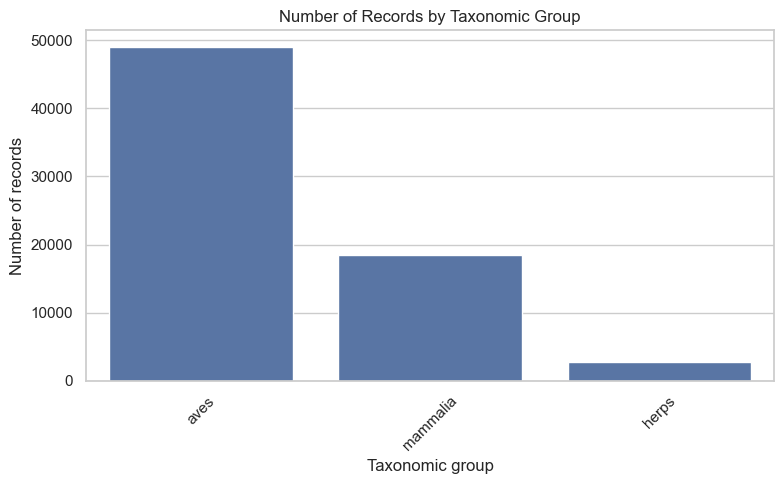

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.barplot(
    data=group_counts,
    x="group",
    y="records"
)

plt.title("Number of Records by Taxonomic Group")
plt.xlabel("Taxonomic group")
plt.ylabel("Number of records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
realm_counts = (
    lpi_clean["realm"]
    .value_counts()
    .reset_index()
)

realm_counts.columns = ["realm", "records"]

realm_counts

,realm,records
0,Nearctic,43026
1,Palearctic,15936
2,IndoPacific,4570
3,Afrotropical,4502
4,Neotropical,2160


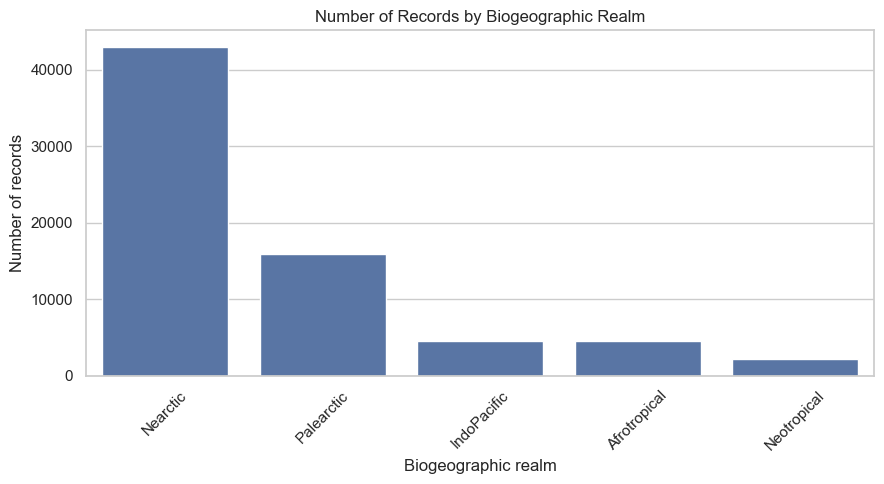

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=realm_counts,
    x="realm",
    y="records"
)

plt.title("Number of Records by Biogeographic Realm")
plt.xlabel("Biogeographic realm")
plt.ylabel("Number of records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
year_counts = (
    lpi_clean["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

year_counts.columns = ["year", "records"]

year_counts.head()

,year,records
0,1950,77
1,1951,67
2,1952,78
3,1953,87
4,1954,80


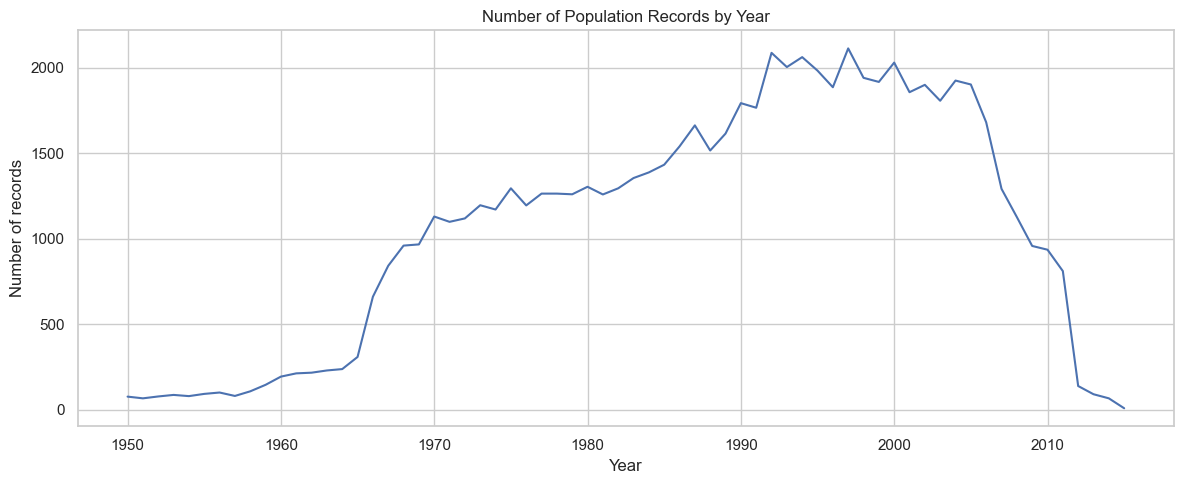

In [42]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=year_counts,
    x="year",
    y="records"
)

plt.title("Number of Population Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [43]:
timeseries_length = (
    lpi_clean
    .groupby("ID")["year"]
    .nunique()
    .reset_index()
)

timeseries_length.columns = ["population_id", "number_of_years"]

timeseries_length.head()

,population_id,number_of_years
0,4,14
1,5,25
2,6,3
3,7,4
4,8,4


In [44]:
timeseries_length["number_of_years"].describe()

count    4077.000000
mean       11.940397
std        12.982669
min         1.000000
25%         3.000000
50%         6.000000
75%        15.000000
max        60.000000
Name: number_of_years, dtype: float64

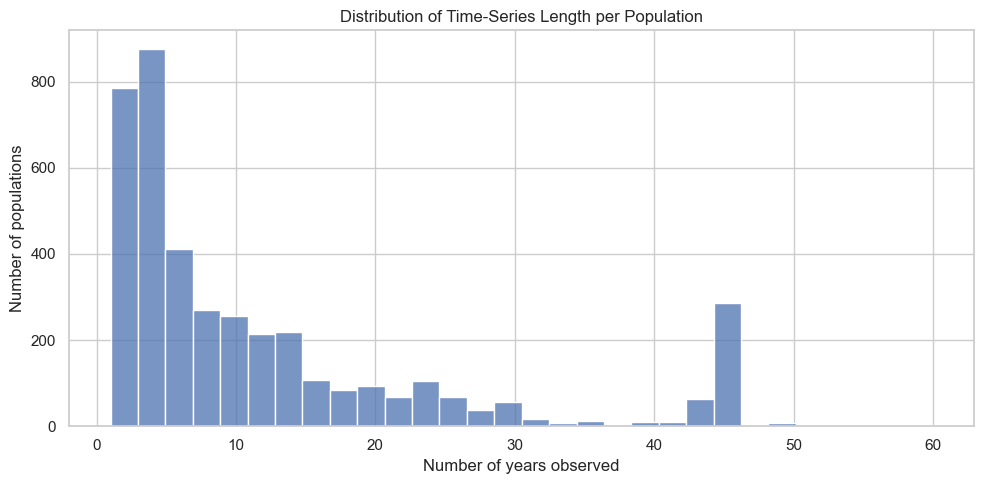

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=timeseries_length,
    x="number_of_years",
    bins=30
)

plt.title("Distribution of Time-Series Length per Population")
plt.xlabel("Number of years observed")
plt.ylabel("Number of populations")
plt.tight_layout()
plt.show()

In [46]:
processed_path = "../data/processed/lpi_clean.csv"

lpi_clean.to_csv(processed_path, index=False)

print(f"Saved cleaned dataset to: {processed_path}")
print(f"Shape: {lpi_clean.shape}")

Saved cleaned dataset to: ../data/processed/lpi_clean.csv
Shape: (70194, 8)
